# DATA PIPELINE & EXPLORATORY DATA ANALYSIS (EDA)
**Objective:** Load raw data, perform initial exploratory data analysis, generate mock data for prototyping, and establish the PyTorch DataLoader pipeline.

## 1. Import Libraries & Setup Directories

## 2. Load Raw Data & Extract Mock Data
Generate a small random subset (5,000 samples) to unblock the Modeling team for training loop construction.

In [7]:
import os
import pandas as pd  

# Create directory structure if it doesn't exist
os.makedirs('../data/raw', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True) 

# Load the original massive dataset (Replace with your actual file path)
# Assuming the file has 'text' and 'label' columns
df_raw = pd.read_csv(r"C:\nlp_project\data\raw\text.csv") 

# Randomly sample 5,000 rows for the team to construct the initial ML pipeline
df_mock = df_raw.sample(n=5000, random_state=42)

# Save the mock dataset to a separate CSV file 
df_mock.to_csv(r"C:\nlp_project\data\raw\mock_data.csv", index=False) 
print(f"Mock dataset successfully generated with {len(df_mock)} rows.") 

Mock dataset successfully generated with 5000 rows.


## 3. Exploratory Data Analysis (EDA)
Perform a comprehensive diagnostic of the raw dataset without altering its structural integrity. The objective is to identify data quality issues, class imbalances, and sequence length outliers to inform the downstream preprocessing and modeling strategies.

### 3.1. Data Check
Diagnose the presence of missing values and duplicate records. No removal actions are taken in this phase.

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud 

# Set global plotting style
sns.set_theme(style="whitegrid")

print("--- Data Health Diagnostics ---")
# Count missing values in each column
missing_values = df_raw.isnull().sum()
print(f"Missing values per column:\n{missing_values}\n")

# Count exact duplicate rows across the entire dataframe
duplicate_count = df_raw.duplicated().sum()
print(f"Total duplicate rows detected: {duplicate_count}")
print("Note: Duplicates and missing values will be handled in the Preprocessing pipeline.") 

--- Data Health Diagnostics ---
Missing values per column:
Unnamed: 0    0
text          0
label         0
dtype: int64

Total duplicate rows detected: 0
Note: Duplicates and missing values will be handled in the Preprocessing pipeline.


### 3.2. Label Distribution Analysis
Visualize the emotion class distribution to assess potential dataset imbalance, which may require techniques like class weighting during the model training phase.

C:\Users\trann\AppData\Local\Temp\ipykernel_28476\321808526.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_raw, x='label', palette='viridis')


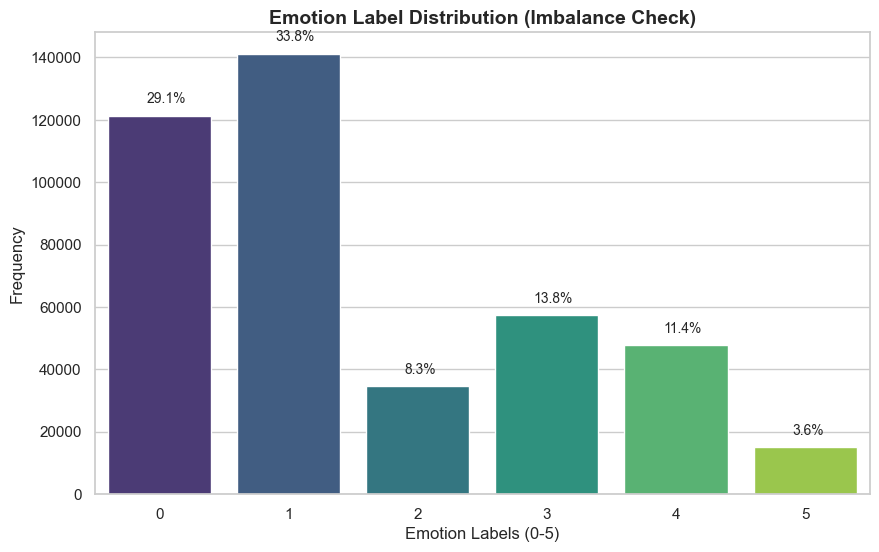

In [9]:
plt.figure(figsize=(10, 6))

# Plot the frequency of each emotion label
ax = sns.countplot(data=df_raw, x='label', palette='viridis')
plt.title('Emotion Label Distribution (Imbalance Check)', fontsize=14, fontweight='bold')
plt.xlabel('Emotion Labels (0-5)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Add percentage annotations on top of each bar
total = len(df_raw)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%' 
    x = p.get_x() + p.get_width() / 2 - 0.1
    y = p.get_y() + p.get_height() + (total * 0.01)
    ax.annotate(percentage, (x, y), size=10)

plt.show()

### 3.3. Text Sequence Length & Outlier Analysis
Calculate the word count for each text sequence to determine the optimal `max_length` parameter for tokenization (e.g., BERT or LSTM padding/truncation).

--- Text Length Statistics ---
count    416809.000000
mean         19.211015
std          11.051049
min           1.000000
25%          11.000000
50%          17.000000
75%          25.000000
max         178.000000
Name: word_count, dtype: float64


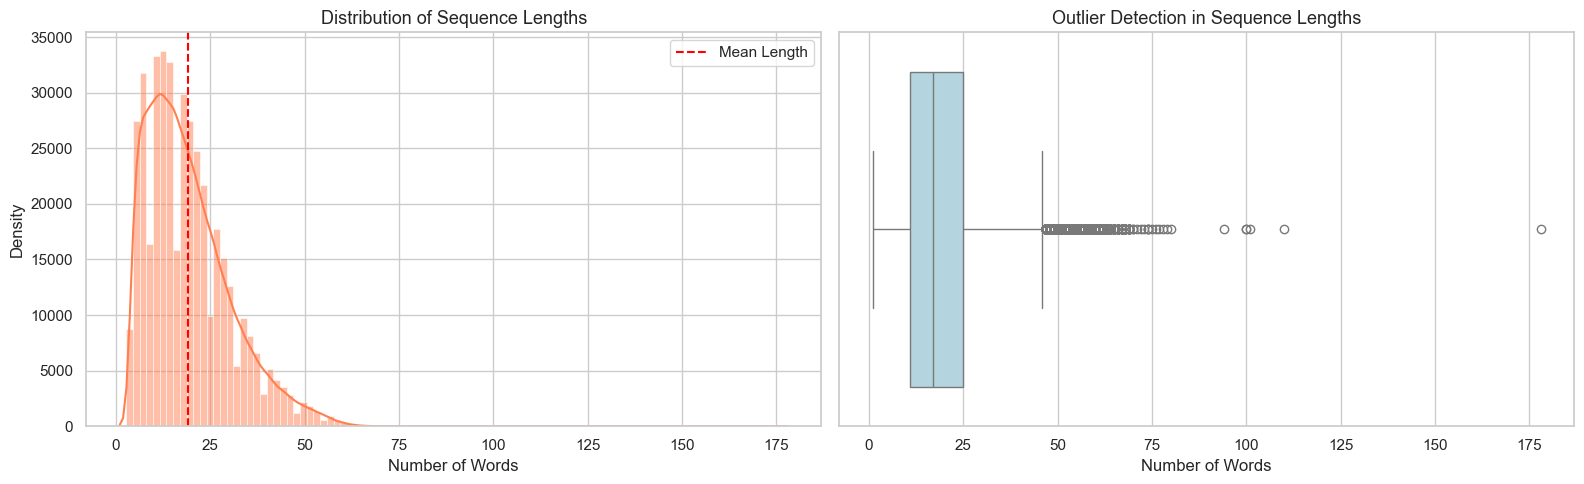

In [10]:
# Calculate sequence length (word count) for each row
df_raw['word_count'] = df_raw['text'].apply(lambda x: len(str(x).split()))

# Display descriptive statistics to identify outliers
print("--- Text Length Statistics ---")
print(df_raw['word_count'].describe())

# Plot the distribution and outliers using a Histogram and a Boxplot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram for distribution
sns.histplot(df_raw['word_count'], bins=100, kde=True, color='coral', ax=axes[0])
axes[0].set_title('Distribution of Sequence Lengths', fontsize=13)
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Density')
axes[0].axvline(df_raw['word_count'].mean(), color='red', linestyle='--', label='Mean Length')
axes[0].legend()

# Boxplot for outlier detection
sns.boxplot(x=df_raw['word_count'], color='lightblue', ax=axes[1])
axes[1].set_title('Outlier Detection in Sequence Lengths', fontsize=13)
axes[1].set_xlabel('Number of Words')

plt.tight_layout()
plt.show() 

### 3.4. Linguistic Insights (Word Cloud)
Extract visual context from the text corpus. We isolate specific classes to observe the most frequently used vocabulary associated with distinct emotion labels.

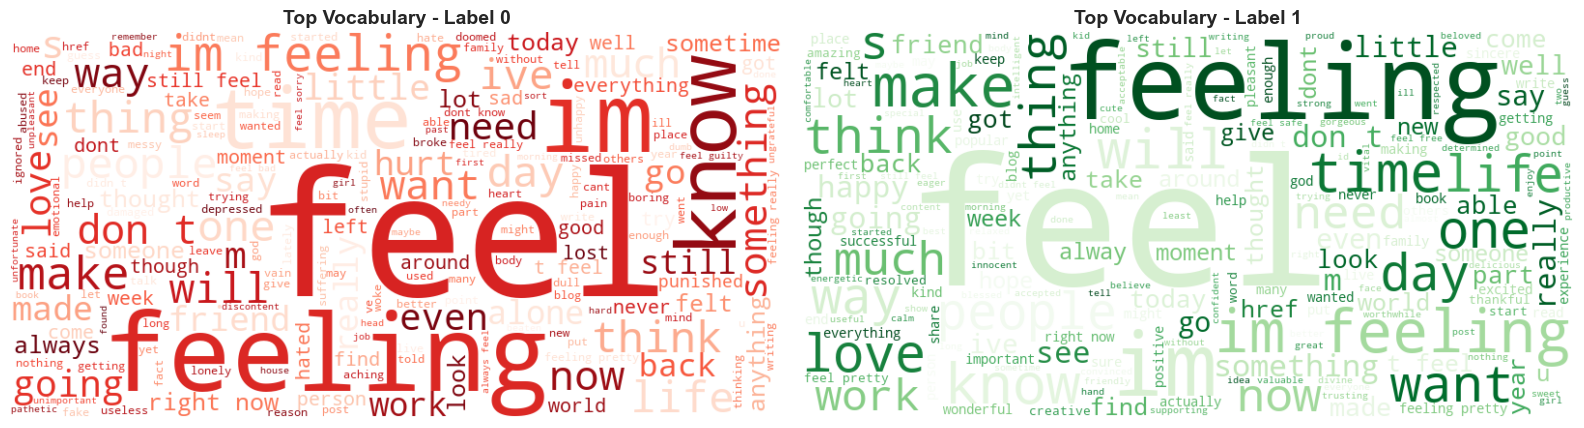

In [11]:
# Create a temporary subset without null texts specifically for visualization purposes
df_vis = df_raw.dropna(subset=['text'])

# Select two contrasting labels for comparison (e.g., Label 0 and Label 1)
# Note: Ensure these labels exist in your dataset
text_label_0 = " ".join(df_vis[df_vis['label'] == 0]['text'].astype(str))
text_label_1 = " ".join(df_vis[df_vis['label'] == 1]['text'].astype(str))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Generate Word Cloud for Label 0
wordcloud_0 = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(text_label_0)
axes[0].imshow(wordcloud_0, interpolation='bilinear')
axes[0].set_title('Top Vocabulary - Label 0', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Generate Word Cloud for Label 1
wordcloud_1 = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(text_label_1)
axes[1].imshow(wordcloud_1, interpolation='bilinear')
axes[1].set_title('Top Vocabulary - Label 1', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show() 

## 4. Execute Modular Data Pipeline & Verify DataLoader
Import the refactored `DataPipelineManager` from our custom `data_pipeline` module. This step demonstrates the separation of concerns: the core pipeline logic is encapsulated in the source code (`.py`), while this notebook serves as the execution and verification environment.

In [ ]:
# Import the encapsulated pipeline classes from the local module
from data_pipeline import EmotionDataset, DataPipelineManager

# Initialize the pipeline manager with the respective file paths
pipeline = DataPipelineManager(
    raw_data_path="../data/raw/text.csv",
    mock_data_output_path="../data/raw/mock_data.csv"
)

# Execute the mock data generation method
df_mock = pipeline.generate_mock_data()

# Construct the PyTorch DataLoader using the generated mock dataframe
mock_loader = pipeline.get_pytorch_loaders(df_mock)

# Extract a single batch to verify tensor shapes and pipeline integrity
sample_texts, sample_labels = next(iter(mock_loader))
print(f"Batch text shape: {len(sample_texts)}")
print(f"Batch label shape: {sample_labels.shape}")  

Batch text shape: 32
Batch label shape: torch.Size([32])
